In [2]:
pip install tensorflow matplotlib scikit-learn pillow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Перевірка наявності GPU
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [4]:
# 1. Build InceptionV3 architecture manually

def inception_module(x, filters):
    f1, f3r, f3, f5r, f5, proj = filters
    
    # 1x1 path
    path1 = layers.Conv2D(f1, (1, 1), padding='same', activation='relu')(x)
    
    # 3x3 path
    path2 = layers.Conv2D(f3r, (1, 1), padding='same', activation='relu')(x)
    path2 = layers.Conv2D(f3, (3, 3), padding='same', activation='relu')(path2)
    
    # 5x5 path
    path3 = layers.Conv2D(f5r, (1, 1), padding='same', activation='relu')(x)
    path3 = layers.Conv2D(f5, (5, 5), padding='same', activation='relu')(path3)
    
    # Pool path
    path4 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    path4 = layers.Conv2D(proj, (1, 1), padding='same', activation='relu')(path4)
    
    return layers.concatenate([path1, path2, path3, path4], axis=-1)

def build_inception_v3(input_shape=(299, 299, 3)):
    inputs = layers.Input(shape=input_shape)
    # STEM
    x = layers.Conv2D(32, (3, 3), strides=(2, 2), activation='relu')(inputs)
    x = layers.Conv2D(32, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2))(x)
    # Inception Blocks
    x = inception_module(x, [64, 48, 64, 8, 16, 32])
    x = inception_module(x, [64, 64, 96, 16, 32, 64])
    x = layers.MaxPooling2D((3, 3), strides=(2, 2))(x)
    
    x = inception_module(x, [128, 128, 192, 32, 96, 64])
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x) 
    
    model = models.Model(inputs, outputs)
    return model


In [5]:
# 2. Data preparation 

base_dir = "/kaggle/input/dogs-cats-images/dataset"
train_dir = os.path.join(base_dir, "training_set")
test_dir = os.path.join(base_dir, "test_set")
img_size = (299, 299)
batch_size = 16
epochs = 15

# Генератор
datagen = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2, 
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='training',
    class_mode='binary'
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='validation',
    class_mode='binary'
)

# Генератор для тестування 
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

Found 6400 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [6]:
# 3. Train model
model = build_inception_v3(input_shape=(*img_size, 3))

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy', 
              metrics=['accuracy'])

cb = [
    callbacks.ModelCheckpoint("inception_lab5_best.h5", monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=cb)



I0000 00:00:1762266600.714228      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1762266610.836947     104 service.cc:148] XLA service 0x7f893c003750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762266610.837760     104 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762266611.824949     104 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/400 ━━━━━━━━━━━━━━━━━━━━ 1:54:59 17s/step - accuracy: 0.6250 - loss: 0.6713

I0000 00:00:1762266620.003520     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5166 - loss: 0.6917
Epoch 1: val_accuracy improved from -inf to 0.59375, saving model to inception_lab5_best.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 187s 425ms/step - accuracy: 0.5167 - loss: 0.6917 - val_accuracy: 0.5938 - val_loss: 0.6688 - learning_rate: 1.0000e-04
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5770 - loss: 0.6658
Epoch 2: val_accuracy improved from 0.59375 to 0.62750, saving model to inception_lab5_best.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 148s 371ms/step - accuracy: 0.5770 - loss: 0.6658 - val_accuracy: 0.6275 - val_loss: 0.6467 - learning_rate: 1.0000e-04
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.6204 - loss: 0.6426
Epoch 3: val_accuracy improved from 0.62750 to 0.63375, saving model to inception_lab5_best.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 146s 366ms/step - accuracy: 0.6204 - loss: 0.6426 - val_accuracy: 0.6338 - val_loss: 0.6406 - learning_rate: 1.0000e-04
Epoch 4/15
400/400

2001/2001 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



--- Оцінка моделі ---
Accuracy: 0.7225
Precision: 0.7480
Recall: 0.6710
F1-score: 0.7074
Classification Report:
               precision    recall  f1-score   support

        cats       0.70      0.77      0.74      1000
        dogs       0.75      0.67      0.71      1000

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



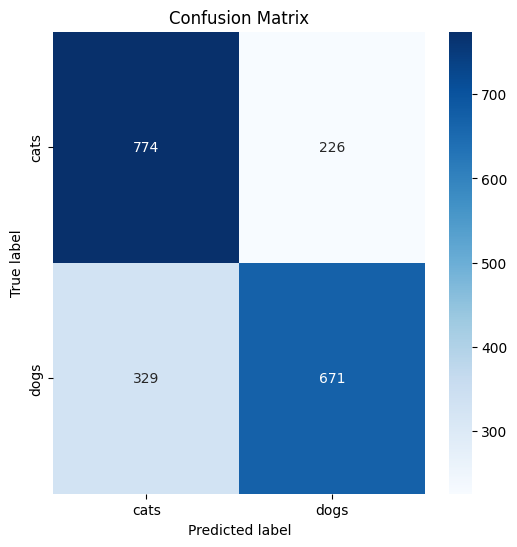

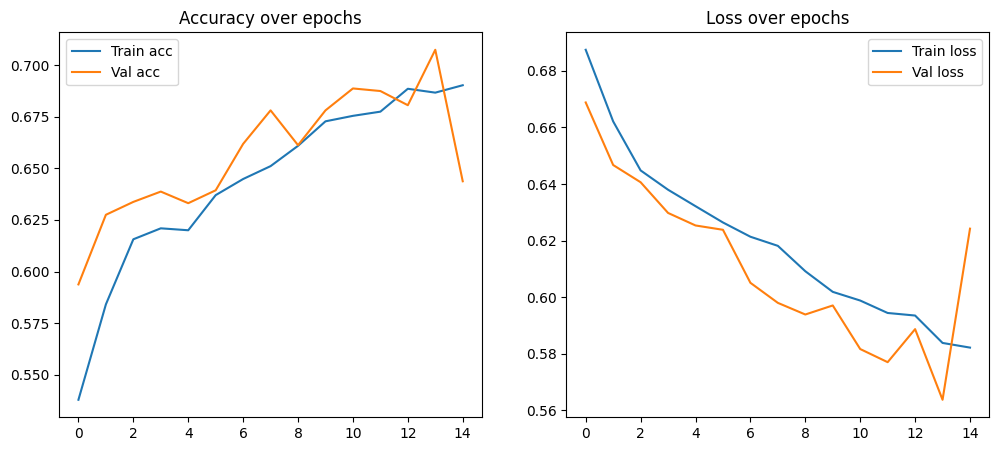

In [7]:
# 4. Evaluate model
model.load_weights("inception_lab5_best.h5")

test_gen.reset() 
Y_pred = model.predict(test_gen, steps=test_gen.samples // test_gen.batch_size + 1)

y_pred = (Y_pred.ravel() > 0.5).astype(int) 
y_true = test_gen.classes

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys()))

print("\n--- Оцінка моделі ---")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print("Classification Report:\n", report)

# Візуалізація Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_gen.class_indices.keys()),
            yticklabels=list(test_gen.class_indices.keys()))
plt.title("Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

# Візуалізація історії навчання
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy over epochs')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()


In [8]:
# 5. Predict an external image 
def predict_image(model, img_path, img_size=(299, 299), class_indices=None):
    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred_prob = model.predict(img_array)[0][0] 
    
    # Визначаємо клас
    class_id = int(pred_prob > 0.5)
    class_labels = {v: k for k, v in class_indices.items()}
    # Якщо клас_id = 1 (Dog)
    # Якщо клас_id = 0 (Cat)
    probability = pred_prob if class_id == 1 else (1 - pred_prob)
    
    return {"class": class_labels[class_id], "probability": float(probability)}


class_map = test_gen.class_indices
# Зображення з тестового набору
external_img = os.path.join(test_dir, 'dogs', 'dog.4001.jpg') 

print("\n--- Прогнозування зовнішнього зображення ---")
try:
    result = predict_image(model, external_img, img_size, class_map)
    print(f"Зображення: {os.path.basename(external_img)}")
    print(f"Прогнозований клас: {result['class']} з імовірністю {result['probability']:.4f}")
except FileNotFoundError:
    print(f"Помилка: Не вдалося знайти файл за шляхом: {external_img}. Перевірте шляхи в Kaggle.")
except Exception as e:
    print(f"Помилка прогнозування: {e}")

# Збереження моделі
model.save("inception_lab5_full.h5")
print("\nSaved model to inception_lab5_full.h5")


--- Прогнозування зовнішнього зображення ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step
Зображення: dog.4001.jpg
Прогнозований клас: dogs з імовірністю 0.7058

Saved model to inception_lab5_full.h5
